# Load Data

In [ ]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

df_train = pd.read_excel('case_1_labeled_data.xlsx')
df_predict = pd.read_excel('case_1_text_to_predict.xlsx')
df_template = pd.read_excel('case_1_template_sheet.xlsx')

print("Data latih (labeled):", df_train.shape)
print("Data prediksi (unlabeled):", df_predict.shape)
print("Sample data:")
print(df_train.head())

Data latih (labeled): (5000, 2)
Data prediksi (unlabeled): (1500, 2)
Sample data:
                                           full_text             label
0  @ARSIPAJA Pret. Di sekolah gw dapet MBG tetep ...  Sasaran Penerima
1  MBG bentuk penggarongan duit negara secara TSM...           Politik
2  @inzhapt_76 @ARSIPAJA Pasal 34 ayat (1) Undang...  Sasaran Penerima
3  Makan Bergizi Gratis bikin masyarakat ngerasa ...  Sasaran Penerima
4  @OniSuryaman Presiden ngotot, paling sebel kal...           Politik


# Explorasi Data

In [5]:
# Cek missing values
print("Missing values di data latih:")
print(df_train.isnull().sum())

Missing values di data latih:
full_text      0
label          0
jumlah_kata    0
dtype: int64


In [6]:
# Cek duplikat
print("Duplikat di data latih: ", df_train['full_text'].duplicated().sum())


Duplikat di data latih:  1


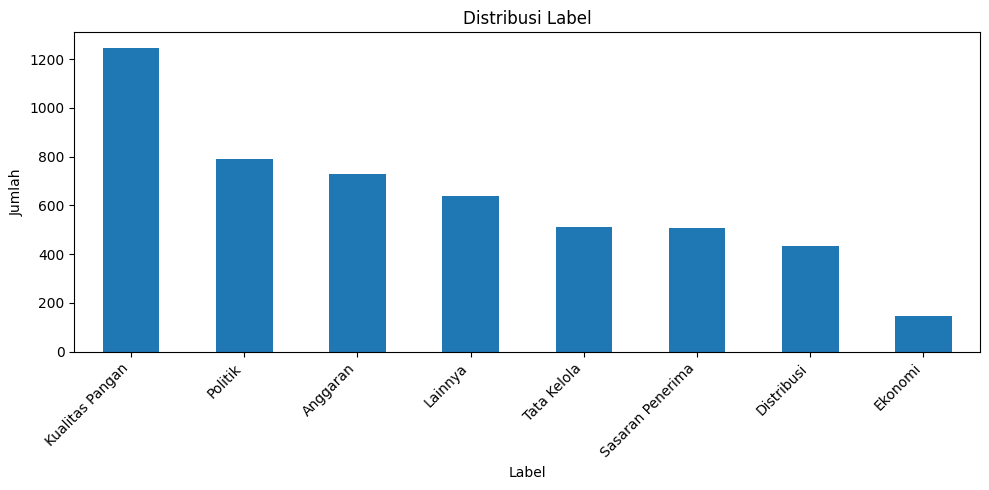

Distribusi label:
label
Kualitas Pangan     1247
Politik              792
Anggaran             727
Lainnya              638
Tata Kelola          511
Sasaran Penerima     507
Distribusi           433
Ekonomi              145
Name: count, dtype: int64


In [2]:
import matplotlib.pyplot as plt

df_train['label'].value_counts().plot(kind='bar', figsize=(10, 5))
plt.title('Distribusi Label')
plt.xlabel('Label')
plt.ylabel('Jumlah')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Distribusi label:")
print(df_train['label'].value_counts())

In [4]:
# Cek panjang teks
df_train['jumlah_kata'] = df_train['full_text'].str.split().str.len()
print("Deskripsi panjang teks di data latih:")
print(df_train['jumlah_kata'].describe())

Deskripsi panjang teks di data latih:
count    5000.00000
mean       20.75280
std        12.62537
min         1.00000
25%        11.00000
50%        17.00000
75%        31.00000
max        68.00000
Name: jumlah_kata, dtype: float64


In [7]:
# Teks kurang dari 3 kata
print("Teks dengan jumlah kurang dari 3 kata:")
print(df_train[df_train['jumlah_kata'] <= 3]['full_text'].values)

Teks dengan jumlah kurang dari 3 kata:
['Siapapun bubarin MBG😭👊' 'MBG BANGSATTT' '@MiskinTV_ mbg gaje🗿'
 '@FaktaSepakbola Trio MBG🔥🔥🔥' '@lovintakie Menu mbg'
 '@tanyakanrl MBG lagi' 'Dukung MBG https://t.co/YMmL86od5u'
 '@CNNIndonesia Ditetel MBG' '@hrdbacot cef mbg?' '@dailyyeva Kritik mbg'
 '@ARSIPAJA Stop mbg!' 'IKN\nMBG' 'Kirain MBG' '@lynglyng___ mbg moment'
 'De javu...mbg banget...' 'Bukan MBG~ https://t.co/cwcq1IInxI'
 '@yawnzdzn Bubarkan MBG!!!' '@krysvall Jatah MBG' 'Makan bergizi gratis'
 '@mulanbilqis Ada...belatungnya MBG.' '@JoshEdits *MBG intensifies*'
 '@munriper mbg paling' 'najis bgt mbg' 'Muak dgn mbg'
 'Ayo sukseskan MBG!' '@kompascom pandemi MBG' 'Seengganya gada mbg'
 '@infjohan mbg wkwkwk' '@ARSIPAJA MBG bro..' 'MBG dari Mizi'
 '@txtfromjogja Mbg taek' '@SatriaKalteng Top mbg' 'mbg gak bergizi'
 '@Riashion_ My MBG👑👑👑' '@miyoyns salam mbg🤭' 'penguras anggaran MBG'
 'MBG noh benerin' '@shycologee mbg kak' '@amberliuc MBG apaan?'
 '@boonekapanda Menunggu mbg' '@rega

# Preprocessing

In [8]:
# Hapus duplikat
df_train = df_train.drop_duplicates(subset='full_text').reset_index(drop=True)
print("Jumlah data setelah hapus duplikat:", len(df_train))

Jumlah data setelah hapus duplikat: 4999


In [9]:
import re
from nltk.corpus import stopwords

STOPWORDS_ID = set(stopwords.words('indonesian'))

# Hapus mention, URL, dan karakter non-alphabet
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    words = [w for w in text.split() if w not in STOPWORDS_ID and len(w) > 2]
    return ' '.join(words)

df_train['clean_text'] = df_train['full_text'].apply(clean_text)
df_predict['clean_text'] = df_predict['full_text'].apply(clean_text)

# Cek hasil
print("Asli   :", df_train['full_text'][0])
print("Bersih :", df_train['clean_text'][0])

Asli   : @ARSIPAJA Pret. Di sekolah gw dapet MBG tetep aja anak-anaknya pada jajan lagi daaan ga semua suka sama menu MBGnya🥲
Bersih : pret sekolah dapet mbg tetep aja anak anaknya jajan daaan suka menu mbgnya


# Modeling

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.model_selection import cross_val_score

X = df_train['clean_text']
y = df_train['label']

# Pipeline menggabungkan dua jenis TF-IDF (word dan char) dan classifier LinearSVC
pipeline = Pipeline([
    ('features', FeatureUnion([
        ('word', TfidfVectorizer(
            ngram_range=(1, 2),
            max_features=80000,
            sublinear_tf=True,
            analyzer='word'
        )),
        ('char', TfidfVectorizer(
            ngram_range=(3, 5),
            max_features=50000,
            sublinear_tf=True,
            analyzer='char_wb'
        ))
    ])),
    ('clf', LinearSVC(
        class_weight='balanced',
        C=0.1,
        max_iter=2000
    ))
])

# Evaluasi cross-validation
scores = cross_val_score(pipeline, X, y, cv=10, scoring='balanced_accuracy')
print(f"Balanced Accuracy per fold: {scores.round(3)}")
print(f"Rata-rata: {scores.mean():.4f}")

c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` expli

Balanced Accuracy per fold: [0.603 0.579 0.672 0.634 0.652 0.634 0.624 0.595 0.626 0.64 ]
Rata-rata: 0.6261


# Hyperparameter Tuning

In [17]:
from sklearn.model_selection import GridSearchCV

# Grid parameter untuk pencarian
param_grid = {
    'clf__C': [0.01, 0.1, 0.5, 1.0],
    'clf__dual': ['auto'],
    'features__word__ngram_range': [(1, 1), (1, 2), (1, 3)],
    'features__word__max_features': [50000, 80000, 100000],
    'features__char__ngram_range': [(2, 4), (3, 5)],
    'features__char__max_features': [30000, 50000]
}

# GridSearchCV untuk mencari parameter terbaik
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=10,
    scoring='balanced_accuracy',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X, y)

print("Parameter terbaik:", grid_search.best_params_)
print("Skor terbaik:", round(grid_search.best_score_, 4))

Fitting 10 folds for each of 144 candidates, totalling 1440 fits
Parameter terbaik: {'clf__C': 0.1, 'clf__dual': 'auto', 'features__char__max_features': 30000, 'features__char__ngram_range': (3, 5), 'features__word__max_features': 100000, 'features__word__ngram_range': (1, 3)}
Skor terbaik: 0.6265


In [18]:
# Evaluasi ulang dengan parameter terbaik
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report

best_pipeline = grid_search.best_estimator_

scores_best = cross_val_score(best_pipeline, X, y, cv=10, scoring='balanced_accuracy')
print(f"Balanced Accuracy per fold: {scores_best.round(3)}")
print(f"Rata-rata: {scores_best.mean():.4f}")

print("\nClassification Report:")
y_pred = cross_val_predict(best_pipeline, X, y, cv=10)
print(classification_report(y, y_pred))

Balanced Accuracy per fold: [0.609 0.589 0.673 0.638 0.649 0.629 0.627 0.599 0.626 0.627]
Rata-rata: 0.6265

Classification Report:
                  precision    recall  f1-score   support

        Anggaran       0.72      0.75      0.74       727
      Distribusi       0.57      0.63      0.60       433
         Ekonomi       0.60      0.74      0.66       145
 Kualitas Pangan       0.72      0.69      0.71      1246
         Lainnya       0.50      0.56      0.53       638
         Politik       0.60      0.52      0.56       792
Sasaran Penerima       0.58      0.61      0.60       507
     Tata Kelola       0.58      0.49      0.53       511

        accuracy                           0.63      4999
       macro avg       0.61      0.63      0.62      4999
    weighted avg       0.63      0.63      0.63      4999



# Inferensi

In [19]:
# Prediksi
predictions = best_pipeline.predict(df_predict['clean_text'])

# simpan ke template
df_template['label'] = predictions
df_template.to_excel('Timeout.xlsx', index=False)

print("Distribusi hasil prediksi:")
print(pd.Series(predictions).value_counts())

Distribusi hasil prediksi:
Kualitas Pangan     350
Anggaran            243
Politik             221
Lainnya             208
Distribusi          151
Sasaran Penerima    151
Tata Kelola         119
Ekonomi              57
Name: count, dtype: int64
